In [1]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
from hydrax.utils.files import get_data_path, get_img_path, mkdir
from hydrax.utils.plotting import draw_t, quat_to_yaw_manual, subsample_to_target
import seaborn as sns
import pandas as pd

img_path = get_img_path()
sns.set(font_scale=1.7, rc={'font.size':17, 'font.family':'serif'})

Loading data for version=bad, seed=10...
Loading data for version=bad, seed=11...
Loading data for version=bad, seed=12...
Loading data for version=uniform, seed=10...
Loading data for version=uniform, seed=11...
Loading data for version=uniform, seed=12...
Loading data for version=exp, seed=10...
Loading data for version=exp, seed=11...
Loading data for version=exp, seed=12...


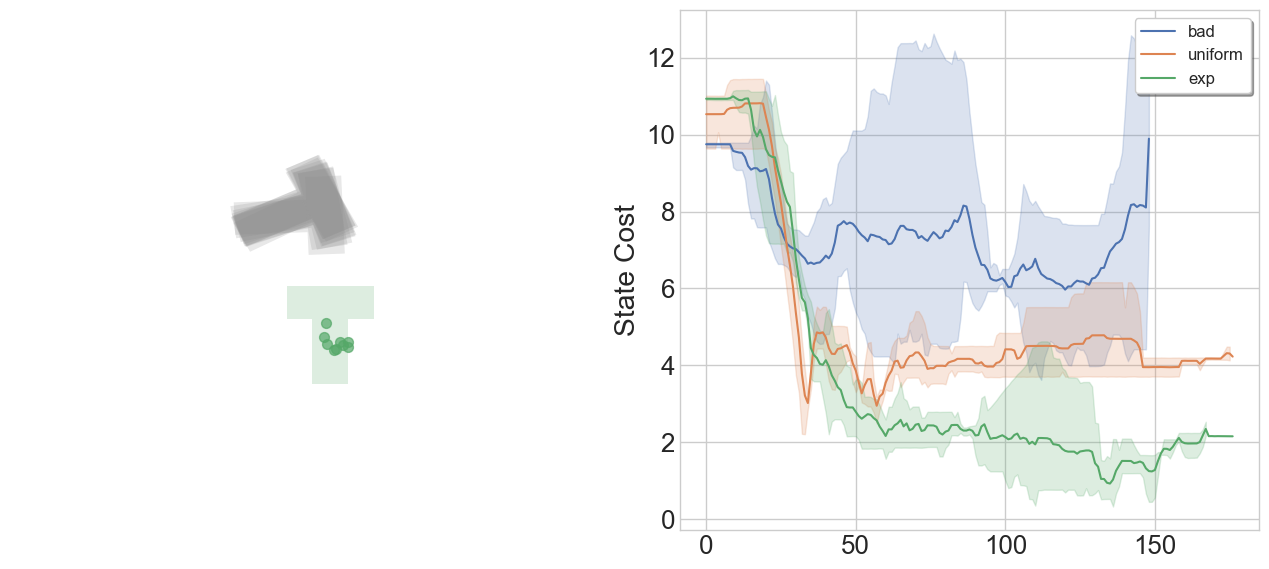

In [2]:
experiments = [[10,11,12]]


for seeds, idx in zip(experiments, range(len(experiments))):
    # Collect all data into long-form DataFrame
    df_list = []
    init_T = []

    for version in ["bad", "uniform", "exp"]:
        for seed in seeds:
            print(f"Loading data for version={version}, seed={seed}...")
            
            path = get_data_path() / "sim-real-dr" / f"fr3_dr_real_MTP_seed{seed}_{version}.pkl"
            with open(path, "rb") as f:
                data = pickle.load(f)
            
            data = subsample_to_target(data, target_steps=300)  
                
            quat = np.array(data[0]['object_quat'])
            # quat to yaw
            jaw = quat_to_yaw_manual(quat[3], quat[0], quat[1], quat[2])
            x = data[5]['object_pos'][0]
            y = data[5]['object_pos'][1]
    
            init_T.append(np.concatenate((np.array([x, y]), np.array([jaw]))))
            timestep = np.arange(min(400, len(data)))
            df_list.append(pd.DataFrame({
                'timestep': timestep,
                'terminal_error': [d["terminal_error"] for d in data[:400]],
                'version': version,
                'seed': seed
            }))

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    df = pd.concat(df_list)
    init_Ts = np.array(init_T)


    init_ee = np.ones((init_Ts.shape[0], 2)) * np.array([0.0425, 0.5])
    init_ee += np.random.uniform(-0.03, 0.03, size=init_ee.shape)
    # plot
    axes[0].scatter(init_ee[:, 0], init_ee[:, 1], s=50, c='C2', alpha=0.7, label='Initial end-effector')
    draw_t(axes[0], 0.0, 0.5, 0.0, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
            face_alpha=0.2, facecolor='C2')

    # draw Ts
    for i in range(init_Ts.shape[0]):
        x, y, yaw = init_Ts[i]
        yaw += -np.pi/2
        draw_t(axes[0], -y, x, yaw, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
            face_alpha=0.2, facecolor='C7')

    axes[0].set_xlim([-0.4, 0.4])
    axes[0].set_ylim([0.2, 1.0])
    # remove ticks
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    # remove border
    for spine in axes[0].spines.values():
        spine.set_visible(False)

    sns.lineplot(data=df, x='timestep', y='terminal_error', hue='version', ax=axes[1])
    if idx == 2:
        axes[1].set_xlabel("Planning Step")
    else:
        axes[1].set_xlabel("")
    axes[1].set_ylabel("State Cost")
    if idx == 0:
        axes[1].legend(
            loc='upper right',           # Position: 'upper right', 'lower center', etc.
            frameon=True,                # Box around legend
            fancybox=True,               # Rounded box
            shadow=True,                 # Drop shadow
            ncol=1,                      # Columns (1=vertical)
            fontsize=12                  # Text size
        )
    else:
        axes[1].legend_.remove()
    plt.tight_layout()
    plt.show()

In [3]:
timesteps = 165
for seeds, idx in zip(experiments, range(len(experiments))):
    # Collect all data into long-form DataFrame
    df_list = []
    init_T = []

    for version in ["bad", "uniform", "exp"]:
        for seed in seeds:
            print(f"Loading data for version={version}, seed={seed}...")
            
            path = get_data_path() / "sim-real-dr" / f"fr3_dr_real_MTP_seed{seed}_{version}.pkl"
            with open(path, "rb") as f:
                data = pickle.load(f)
                print(data[0].keys())
            
            quat = np.array(data[0]['object_quat'])
            # quat to yaw
            jaw = quat_to_yaw_manual(quat[3], quat[0], quat[1], quat[2]) 

            timestep = np.arange(min(timesteps, len(data)))
            df_list.append(pd.DataFrame({
                'timestep': timestep,
                'terminal_error': [d["terminal_error"] for d in data[:timesteps]],
                'version': version,
                'seed': seed,
                'block_vel': [d["block_vel"] for d in data[:timesteps]],
                'distances': [d["distances"] for d in data[:timesteps]], 
                'object_pose': [d["object_pos"] + d['object_quat'] for d in data[:timesteps]],  # x, y, z, qx, qy, qz, qw
                'domain_weights': [d["domain_weights"] for d in data[:timesteps]] if version == "exp" else [None]*len(timestep),
            }))

    plt.style.use('seaborn-v0_8-whitegrid')
    # fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    df = pd.concat(df_list)
    
df_uniform = df[df['version'] == 'uniform']
df_exp = df[df['version'] == 'exp']

Loading data for version=bad, seed=10...
dict_keys(['time', 'planning_time', 'object_pos', 'object_quat', 'ee_pos', 'terminal_error', 'action', 'block_vel', 'distances'])
Loading data for version=bad, seed=11...
dict_keys(['time', 'planning_time', 'object_pos', 'object_quat', 'ee_pos', 'terminal_error', 'action', 'block_vel', 'distances'])
Loading data for version=bad, seed=12...
dict_keys(['time', 'planning_time', 'object_pos', 'object_quat', 'ee_pos', 'terminal_error', 'action', 'block_vel', 'distances'])
Loading data for version=uniform, seed=10...
dict_keys(['time', 'planning_time', 'object_pos', 'object_quat', 'ee_pos', 'terminal_error', 'action', 'block_vel', 'distances'])
Loading data for version=uniform, seed=11...
dict_keys(['time', 'planning_time', 'object_pos', 'object_quat', 'ee_pos', 'terminal_error', 'action', 'block_vel', 'distances', 'domain_weights'])
Loading data for version=uniform, seed=12...
dict_keys(['time', 'planning_time', 'object_pos', 'object_quat', 'ee_pos',

(9, 10)


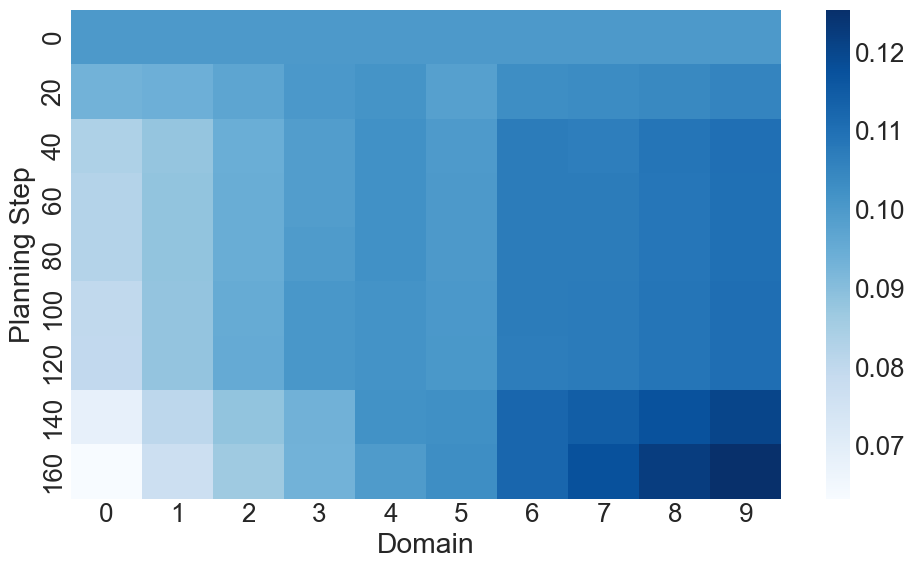

<Figure size 640x480 with 0 Axes>

In [4]:
domain_weights = np.vstack(df_exp[df_exp['seed'] == 10]['domain_weights'].values)[::20]
print(domain_weights.shape)


# heatmap table of domain weights over time
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(domain_weights, ax=ax, cmap='Blues')
ax.set_xlabel('Domain')
ax.set_ylabel('Planning Step')
ax.set_yticklabels(np.arange(0, domain_weights.shape[0]*20, 20))

plt.tight_layout()
plt.show()
mkdir(f"{img_path}/fr3/dr")
plt.savefig(f"{img_path}/fr3/dr/fr3_domain_weights_masses.pdf", bbox_inches='tight')
